In [11]:
import pandas as pd

# ==========================================
# 1. Load Base Data Files
# ==========================================
print("Loading Base File 1...")
df_base1 = pd.read_csv(r"PUDF1Q2019_tab-delimited\PUDF_base1_1q2019_tab.txt", sep='\t', dtype=str)

print("Loading Base File 2...")
df_base2 = pd.read_csv(r"PUDF1Q2019_tab-delimited\PUDF_base2_1q2019_tab.txt", sep='\t', dtype=str)

# 2. Stitch them together
print("Merging base files...")
df_raw = pd.concat([df_base1, df_base2], ignore_index=True)
df_raw.columns = df_raw.columns.str.strip()

# ==========================================
# 3. Extract columns from Base file
# ==========================================
columns_to_keep = [
    "RECORD_ID", "SEX_CODE", "PAT_AGE", "RACE", "ETHNICITY",
    "PAT_ZIP", "SOURCE_OF_ADMISSION", "PRINC_DIAG_CODE",
    "EMERGENCY_DEPT_FLAG", "LENGTH_OF_STAY", "FIRST_PAYMENT_SRC",
    "TOTAL_CHARGES",
    # --- NEW COLUMNS ---
    "PAT_STATUS",              # Discharge disposition (home, transferred, admitted, etc.)
    "SECONDARY_PAYMENT_SRC",   # Dual coverage affects billing patterns
    "TYPE_OF_BILL",            # Facility type + care type + claim sequence
]
df_vault = df_raw[columns_to_keep].copy()
df_vault["RECORD_ID"] = df_vault["RECORD_ID"].str.strip()

# ==========================================
# 4. Translate codes to English
# ==========================================
print("Translating codes to English...")

race_mapping = {
    '1': 'American Indian/Eskimo/Aleut',
    '2': 'Asian or Pacific Islander',
    '3': 'Black',
    '4': 'White',
    '5': 'Other'
}
df_vault['RACE'] = df_vault['RACE'].map(race_mapping)

sex_mapping = {'M': 'Male', 'F': 'Female', 'U': 'Unknown'}
df_vault['SEX_CODE'] = df_vault['SEX_CODE'].map(sex_mapping)

payer_mapping = {
    '09': 'Self Pay',
    '12': 'Medicare Part A', 'MA': 'Medicare Part A',
    '13': 'Medicare Part B', 'MB': 'Medicare Part B',
    '14': 'Medicaid', 'MC': 'Medicaid',
    '16': 'Workers Compensation', 'WC': 'Workers Compensation',
    'CI': 'Commercial Insurance',
    'BL': 'Blue Cross/Blue Shield',
    'HM': 'HMO',
    'ZZ': 'Charity/Indigent/Unknown',
    'DS': 'Disability Insurance',
    'LI': 'Liability',
    'TV': 'Title V',
    'CH': 'CHAMPUS',
    'VA': 'Veterans Administration',
    'OF': 'Other Federal Program',
    '10': 'Central Certification',
    '11': 'Other Non-Federal',
    '15': 'Indemnity Insurance',
    'AM': 'Automobile Medical',
    'LM': 'Liability Medical',
}
df_vault['FIRST_PAYMENT_SRC'] = df_vault['FIRST_PAYMENT_SRC'].map(payer_mapping).fillna('Other Insurance')
df_vault['SECONDARY_PAYMENT_SRC'] = df_vault['SECONDARY_PAYMENT_SRC'].map(payer_mapping).fillna('Other/None')

# Simplify PAT_STATUS into meaningful groups
pat_status_mapping = {
    '01': 'Home/Self-Care',
    '02': 'Transfer-ShortTerm',
    '03': 'Transfer-SNF',
    '04': 'Transfer-Custodial',
    '05': 'Transfer-Cancer/Children',
    '06': 'Home-HomeHealth',
    '07': 'Left-AMA',
    '09': 'Admitted-Inpatient',
    '20': 'Expired',
    '30': 'Still Patient',
    '40': 'Expired-Home',
    '41': 'Expired-Facility',
    '42': 'Expired-Unknown',
    '43': 'Transfer-Federal',
    '50': 'Hospice-Home',
    '51': 'Hospice-Facility',
    '61': 'Transfer-SwingBed',
    '62': 'Transfer-Rehab',
    '63': 'Transfer-LTCH',
    '64': 'Transfer-Medicaid-NF',
    '65': 'Transfer-Psych',
    '66': 'Transfer-CAH',
    '70': 'Transfer-Other',
}
df_vault['PAT_STATUS'] = df_vault['PAT_STATUS'].str.strip().map(pat_status_mapping).fillna('Other')

# Simplify TYPE_OF_BILL: extract the care type (2nd digit)
# 1st digit = facility type, 2nd digit = care type, 3rd digit = claim sequence
df_vault['TYPE_OF_BILL'] = df_vault['TYPE_OF_BILL'].str.strip()
bill_care_type = {
    '1': 'Inpatient-PartA',
    '2': 'Inpatient-PartB',
    '3': 'Outpatient',
    '4': 'Outpatient-PartB',
    '5': 'IntermediateCare-I',
    '6': 'IntermediateCare-II',
    '7': 'Subacute-III',
    '8': 'SwingBed',
}
# Extract 2nd character as care type
df_vault['CARE_TYPE'] = df_vault['TYPE_OF_BILL'].str[1].map(bill_care_type).fillna('Other')
# Drop TYPE_OF_BILL now that we have CARE_TYPE
df_vault = df_vault.drop(columns=['TYPE_OF_BILL'])

# ==========================================
# 7. Convert numeric columns
# ==========================================
df_vault['TOTAL_CHARGES'] = pd.to_numeric(df_vault['TOTAL_CHARGES'], errors='coerce')
df_vault['LENGTH_OF_STAY'] = pd.to_numeric(df_vault['LENGTH_OF_STAY'], errors='coerce')

# ==========================================
# 8. Drop rows missing critical data
# ==========================================
df_vault = df_vault.dropna()

print(f"\n--- Data Cleaning Complete! ---")
print(f"Total rows after cleaning: {len(df_vault)}")
print(f"\nColumns in final dataset ({len(df_vault.columns)}):")
for col in df_vault.columns:
    print(f"  - {col}")
print(f"\nHere is a peek at your Patient Vault:")
print(df_vault.head())

# ==========================================
# 9. Save the FULL dataset (no sampling)
# ==========================================
df_vault.to_csv("Cleaned_Patient_Vault.csv", index=False)
print("\nSaved successfully as 'Cleaned_Patient_Vault.csv'!")

Loading Base File 1...
Loading Base File 2...
Merging base files...
Translating codes to English...

--- Data Cleaning Complete! ---
Total rows after cleaning: 706472

Columns in final dataset (15):
  - RECORD_ID
  - SEX_CODE
  - PAT_AGE
  - RACE
  - ETHNICITY
  - PAT_ZIP
  - SOURCE_OF_ADMISSION
  - PRINC_DIAG_CODE
  - EMERGENCY_DEPT_FLAG
  - LENGTH_OF_STAY
  - FIRST_PAYMENT_SRC
  - TOTAL_CHARGES
  - PAT_STATUS
  - SECONDARY_PAYMENT_SRC
  - CARE_TYPE

Here is a peek at your Patient Vault:
      RECORD_ID SEX_CODE PAT_AGE   RACE ETHNICITY PAT_ZIP SOURCE_OF_ADMISSION  \
0  120190000375   Female      18  White         2   78418                   2   
1  120190000376     Male      14  White         2   78335                   1   
2  120190000377   Female      19  White         2   78336                   2   
3  120190000378     Male      14  White         2   78411                   2   
4  120190000379     Male      15  White         2   78414                   2   

  PRINC_DIAG_CODE E

Loading the full Patient Vault...


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\1638659147.py:15: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")


Total rows available: 706472

--- Running 100 bootstrap iterations (this will take a while) ---



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

Run 10/100...


...

Run 90/100...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

Run 100/100...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC


  MARKOV BLANKET STABILITY REPORT  (100 bootstrap runs)
Variable                  Clinical (LOS)     Financial (TC)    
-----------------------------------------------------------------
CARE_TYPE                 6/100 (6%)         0/100 (0%)        
EMERGENCY_DEPT_FLAG       7/100 (7%)         97/100 (97%)      
ETHNICITY                 0/100 (0%)         6/100 (6%)        
FIRST_PAYMENT_SRC         0/100 (0%)         0/100 (0%)        
PAT_AGE                   1/100 (1%)         100/100 (100%)    
PAT_STATUS                0/100 (0%)         0/100 (0%)        
PAT_ZIP                   0/100 (0%)         0/100 (0%)        
PRINC_DIAG_CODE           0/100 (0%)         0/100 (0%)        
RACE                      0/100 (0%)         6/100 (6%)        
SECONDARY_PAYMENT_SRC     0/100 (0%)         0/100 (0%)        
SEX_CODE                  100/100 (100%)     99/100 (99%)      
SOURCE_OF_ADMISSION       99/100 (99%)       99/100 (99%)      
---------------------------------------------

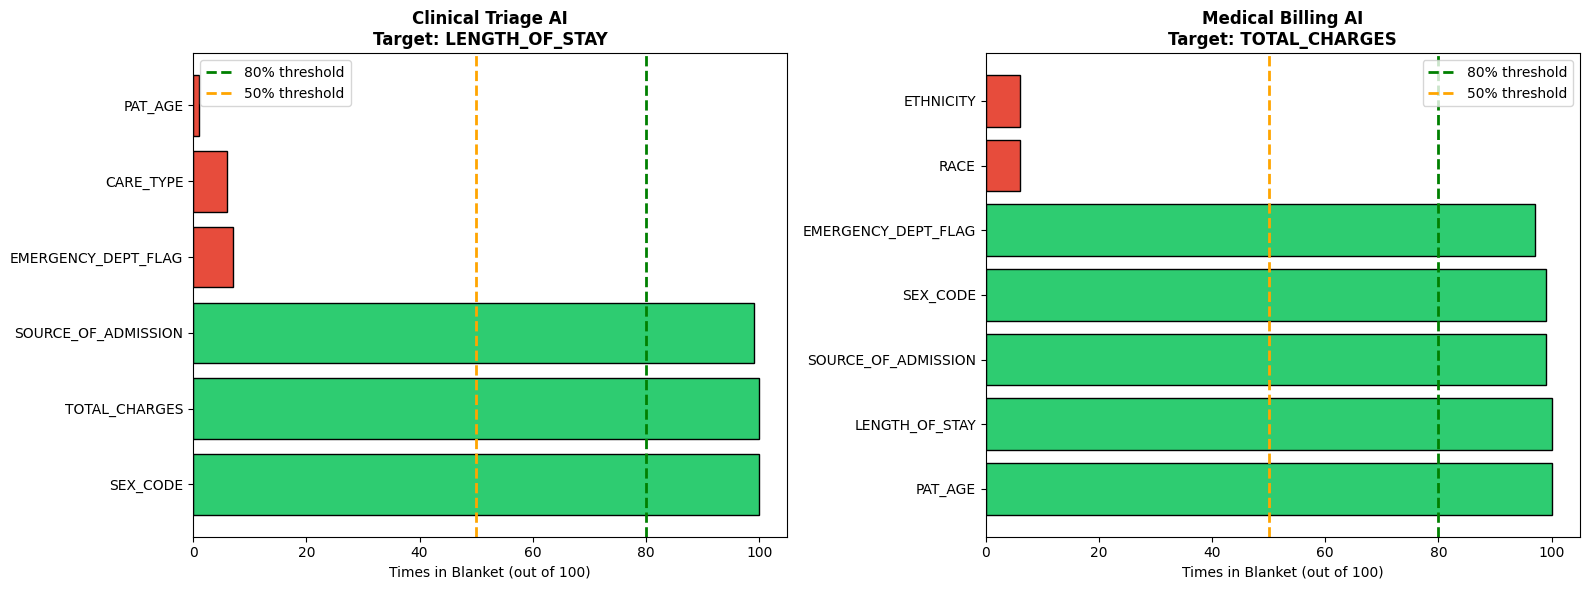

Stability chart saved as 'markov_blanket_stability.png'


  PREDICTION VALIDATION (Random Forest, 5-fold CV)


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\1638659147.py:145: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")



Running 5-fold cross-validation...


  Clinical Triage AI
  Target: LENGTH_OF_STAY
  Blanket vars: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES']
  ---
  ALL features (13 vars):     0.5755 (+/- 0.0028)
  BLANKET only  (3 vars):     0.5353 (+/- 0.0013)
  Accuracy drop:                  0.0402
  Features eliminated:            10
  >>> SMALL DROP — blanket captures most of the signal

  Medical Billing AI
  Target: TOTAL_CHARGES
  Blanket vars: ['SOURCE_OF_ADMISSION', 'PAT_AGE', 'SEX_CODE', 'LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG']
  ---
  ALL features (13 vars):     0.6043 (+/- 0.0041)
  BLANKET only  (5 vars):     0.5356 (+/- 0.0037)
  Accuracy drop:                  0.0687
  Features eliminated:            8
  >>> NOTABLE DROP — consider adding borderline (50%+) variables


  FINAL DATA MINIMIZATION SUMMARY

  Clinical AI (LENGTH_OF_STAY):
    Keep: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES']
    Accuracy: 0.5353 vs 0.5755 (all features)

  Financial AI (TOTAL_CHARGES):

In [15]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. LOAD FULL DATASET
# ==========================================
print("Loading the full Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows available: {len(df_vault)}")

# ==========================================
# 2. BOOTSTRAP SETTINGS
# ==========================================
N_RUNS = 100
SAMPLE_SIZE = 100000
STABILITY_THRESHOLD = 0.80  # 80% = stable core

clinical_counter = Counter()
financial_counter = Counter()

# ==========================================
# 3. BOOTSTRAP LOOP
# ==========================================
print(f"\n--- Running {N_RUNS} bootstrap iterations (this will take a while) ---\n")

for i in range(N_RUNS):
    if (i + 1) % 10 == 0:
        print(f"Run {i + 1}/{N_RUNS}...")

    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

# ==========================================
# 4. STABILITY REPORT
# ==========================================
# List ALL variables (not just ones that appeared in a blanket)
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}")
print("-" * 65)

# ==========================================
# 5. AUTO-EXTRACT STABLE BLANKET VARIABLES
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 6. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if clinical_counter:
    vars_c = sorted(clinical_counter.keys(), key=lambda x: clinical_counter[x], reverse=True)
    counts_c = [clinical_counter[v] for v in vars_c]
    colors_c = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_c]
    axes[0].barh(vars_c, counts_c, color=colors_c, edgecolor='black')
    axes[0].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[0].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[0].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[0].set_title("Clinical Triage AI\nTarget: LENGTH_OF_STAY", fontweight='bold')
    axes[0].legend()

if financial_counter:
    vars_f = sorted(financial_counter.keys(), key=lambda x: financial_counter[x], reverse=True)
    counts_f = [financial_counter[v] for v in vars_f]
    colors_f = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_f]
    axes[1].barh(vars_f, counts_f, color=colors_f, edgecolor='black')
    axes[1].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[1].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[1].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[1].set_title("Medical Billing AI\nTarget: TOTAL_CHARGES", fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.savefig("markov_blanket_stability.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability.png'")

# ==========================================
# 7. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

# Use a 50k sample for model training
df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")
df_pred = df_pred.drop(columns=["RECORD_ID"])
df_pred = df_pred.sample(n=50000, random_state=42).copy()

# Discretize same as before
df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Encode for sklearn
for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    all_features = [c for c in df.columns if c != target]
    y = df[target]

    # Model A: ALL features
    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    # Model B: BLANKET ONLY
    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 8. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL DATA MINIMIZATION SUMMARY")
print("=" * 65)
print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Keep: {clinical_blanket}")
print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Keep: {financial_blanket}")
print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  Conclusion: Collect ONLY the blanket variables.")
print(f"  Everything else can be dropped with minimal accuracy loss.")
print("=" * 65)

Loading the full Patient Vault...


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\1076529303.py:15: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")


Total rows available: 706472

--- Running 100 bootstrap iterations (this will take a while) ---



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

Run 10/100...


...

Run 90/100...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

Run 100/100...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC


  MARKOV BLANKET STABILITY REPORT  (100 bootstrap runs)
Variable                  Clinical (LOS)     Financial (TC)    
-----------------------------------------------------------------
CARE_TYPE                 6/100 (6%)         0/100 (0%)        
EMERGENCY_DEPT_FLAG       7/100 (7%)         97/100 (97%)      
ETHNICITY                 0/100 (0%)         6/100 (6%)        
FIRST_PAYMENT_SRC         0/100 (0%)         0/100 (0%)        
PAT_AGE                   1/100 (1%)         100/100 (100%)    
PAT_STATUS                0/100 (0%)         0/100 (0%)        
PAT_ZIP                   0/100 (0%)         0/100 (0%)        
PRINC_DIAG_CODE           0/100 (0%)         0/100 (0%)        
RACE                      0/100 (0%)         6/100 (6%)        
SECONDARY_PAYMENT_SRC     0/100 (0%)         0/100 (0%)        
SEX_CODE                  100/100 (100%)     99/100 (99%)      
SOURCE_OF_ADMISSION       99/100 (99%)       99/100 (99%)      
---------------------------------------------

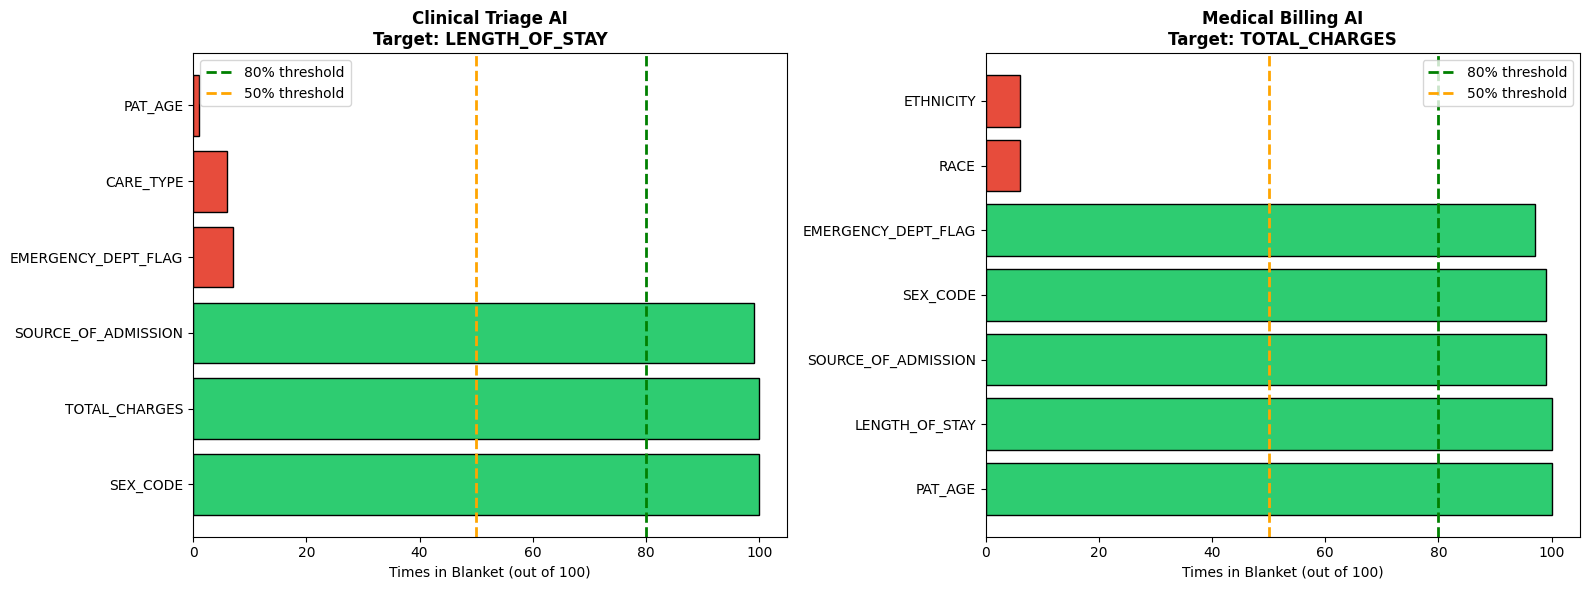

Stability chart saved as 'markov_blanket_stability.png'


  PREDICTION VALIDATION (Random Forest, 5-fold CV)


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\1076529303.py:145: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")



Running 5-fold cross-validation...


  Clinical Triage AI
  Target: LENGTH_OF_STAY
  Blanket vars: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES']
  ---
  ALL features (13 vars):     0.5755 (+/- 0.0028)
  BLANKET only  (3 vars):     0.5353 (+/- 0.0013)
  Accuracy drop:                  0.0402
  Features eliminated:            10
  >>> SMALL DROP — blanket captures most of the signal

  Medical Billing AI
  Target: TOTAL_CHARGES
  Blanket vars: ['SOURCE_OF_ADMISSION', 'PAT_AGE', 'SEX_CODE', 'LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG']
  ---
  ALL features (13 vars):     0.6043 (+/- 0.0041)
  BLANKET only  (5 vars):     0.5356 (+/- 0.0037)
  Accuracy drop:                  0.0687
  Features eliminated:            8
  >>> NOTABLE DROP — consider adding borderline (50%+) variables


  FINAL DATA MINIMIZATION SUMMARY

  Clinical AI (LENGTH_OF_STAY):
    Keep: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES']
    Accuracy: 0.5353 vs 0.5755 (all features)

  Financial AI (TOTAL_CHARGES):

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

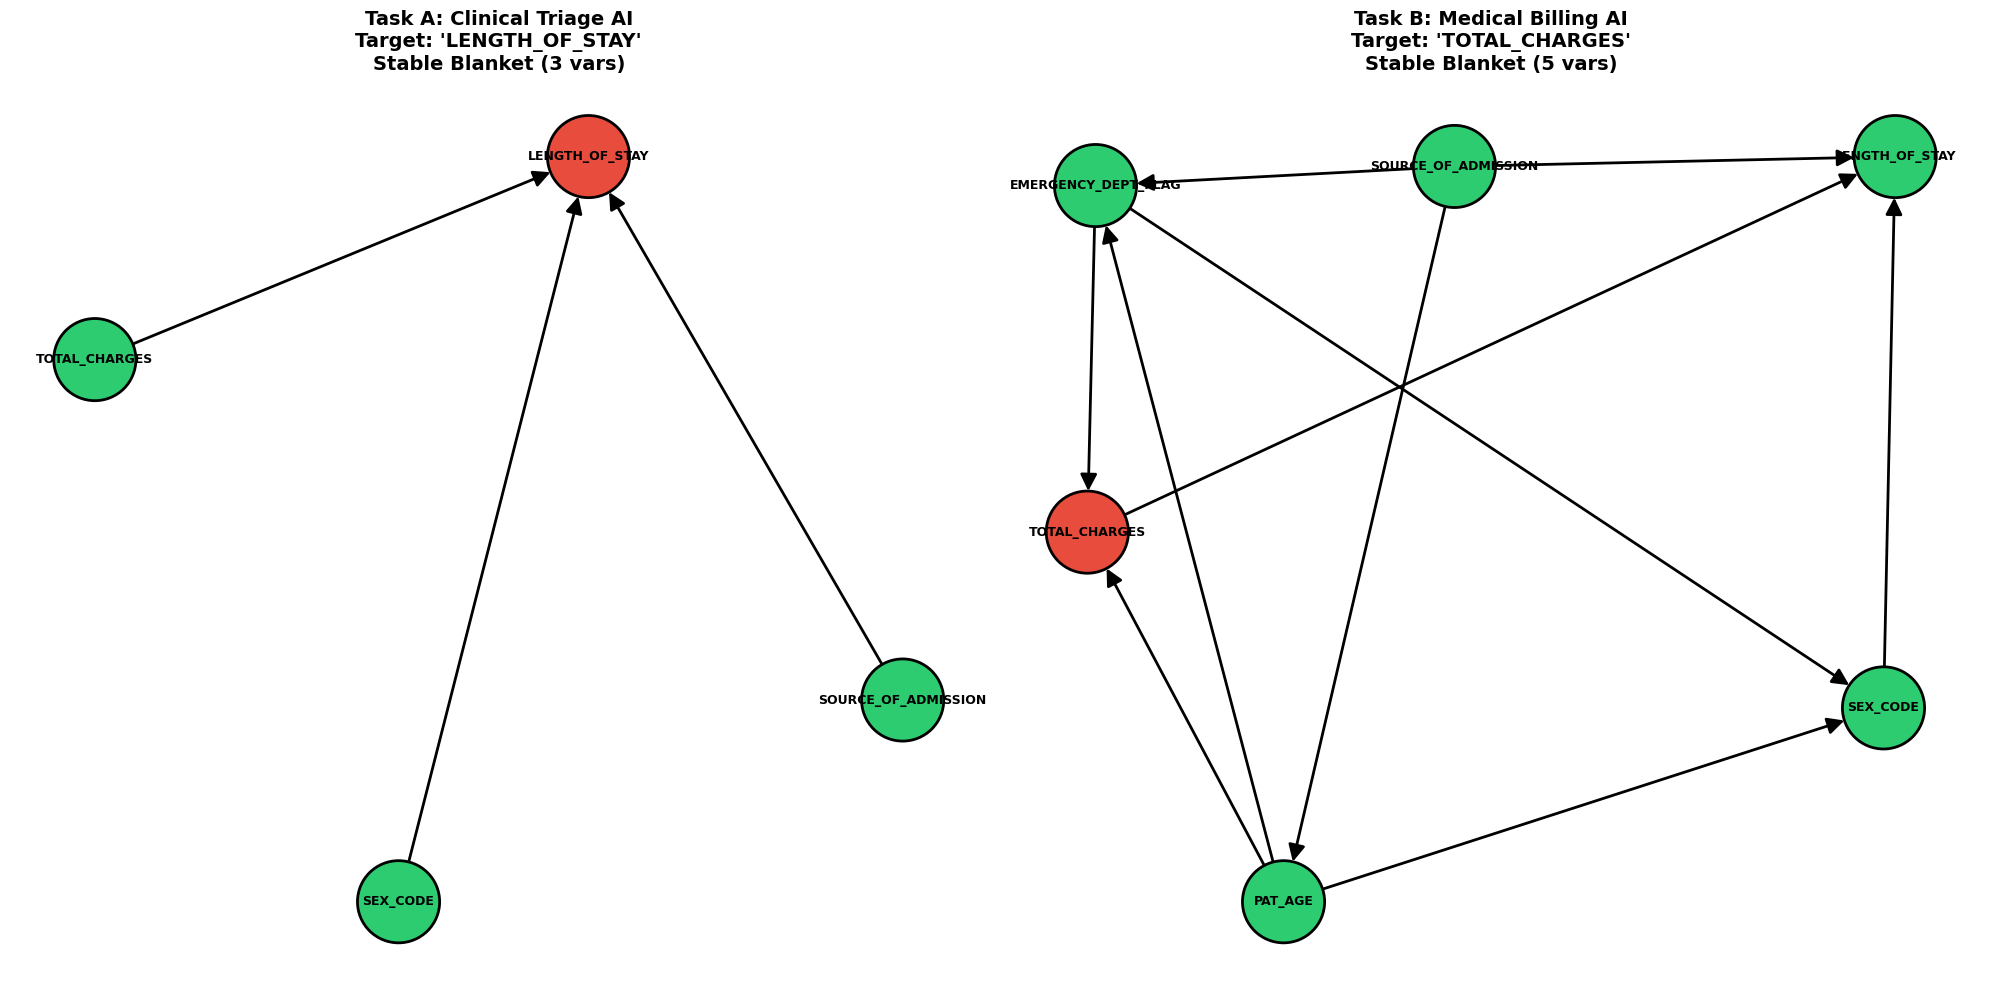

Network graphs saved as 'markov_blanket_graphs.png'


In [16]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. LOAD FULL DATASET
# ==========================================
print("Loading the full Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows available: {len(df_vault)}")

# ==========================================
# 2. BOOTSTRAP SETTINGS
# ==========================================
N_RUNS = 100
SAMPLE_SIZE = 100000  # 100k samples from 706k for maximum stability
STABILITY_THRESHOLD = 0.80  # 80% = stable core

clinical_counter = Counter()
financial_counter = Counter()

# ==========================================
# 3. BOOTSTRAP LOOP
# ==========================================
print(f"\n--- Running {N_RUNS} bootstrap iterations (this will take a while) ---\n")

for i in range(N_RUNS):
    if (i + 1) % 10 == 0:
        print(f"Run {i + 1}/{N_RUNS}...")

    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

# ==========================================
# 4. STABILITY REPORT
# ==========================================
# List ALL variables (not just ones that appeared in a blanket)
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}")
print("-" * 65)

# ==========================================
# 5. AUTO-EXTRACT STABLE BLANKET VARIABLES
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 6. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if clinical_counter:
    vars_c = sorted(clinical_counter.keys(), key=lambda x: clinical_counter[x], reverse=True)
    counts_c = [clinical_counter[v] for v in vars_c]
    colors_c = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_c]
    axes[0].barh(vars_c, counts_c, color=colors_c, edgecolor='black')
    axes[0].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[0].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[0].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[0].set_title("Clinical Triage AI\nTarget: LENGTH_OF_STAY", fontweight='bold')
    axes[0].legend()

if financial_counter:
    vars_f = sorted(financial_counter.keys(), key=lambda x: financial_counter[x], reverse=True)
    counts_f = [financial_counter[v] for v in vars_f]
    colors_f = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_f]
    axes[1].barh(vars_f, counts_f, color=colors_f, edgecolor='black')
    axes[1].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[1].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[1].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[1].set_title("Medical Billing AI\nTarget: TOTAL_CHARGES", fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.savefig("markov_blanket_stability.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability.png'")

# ==========================================
# 7. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

# Use a 50k sample for model training
df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")
df_pred = df_pred.drop(columns=["RECORD_ID"])
df_pred = df_pred.sample(n=50000, random_state=42).copy()

# Discretize same as before
df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Encode for sklearn
for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    all_features = [c for c in df.columns if c != target]
    y = df[target]

    # Model A: ALL features
    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    # Model B: BLANKET ONLY
    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 8. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL DATA MINIMIZATION SUMMARY")
print("=" * 65)
print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Keep: {clinical_blanket}")
print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Keep: {financial_blanket}")
print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  Conclusion: Collect ONLY the blanket variables.")
print(f"  Everything else can be dropped with minimal accuracy loss.")
print("=" * 65)

# ==========================================
# 9. MARKOV BLANKET NETWORK GRAPHS
# ==========================================
import networkx as nx

print("\n\nGenerating Markov Blanket network diagrams...")
print("Running one final structure learning on a large sample for the graph edges...")

# Learn one final structure on a big sample for the graph
df_graph = df_vault.sample(n=min(100000, len(df_vault)), random_state=99).copy()
df_graph['TOTAL_CHARGES'] = pd.qcut(df_graph['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_graph['LENGTH_OF_STAY'] = pd.qcut(df_graph['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')
df_graph = df_graph.astype(str)

hc_final = HillClimbSearch(df_graph)
final_model = hc_final.estimate(scoring_method="bic-d")
bn_final = DiscreteBayesianNetwork(final_model.edges())

G_full = nx.DiGraph()
G_full.add_nodes_from(list(bn_final.nodes()))
G_full.add_edges_from(list(bn_final.edges()))

targets = {
    "Task A: Clinical Triage AI": ("LENGTH_OF_STAY", clinical_blanket),
    "Task B: Medical Billing AI": ("TOTAL_CHARGES", financial_blanket)
}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (title, (target_node, mb_nodes)) in zip(axes, targets.items()):
    # Build subgraph of target + its stable blanket members
    focus_nodes = [target_node] + mb_nodes
    sub_G = G_full.subgraph(focus_nodes).copy()
    
    # Also add any edges from the full graph between these nodes
    # (some blanket members may not have edges in this particular run,
    #  but we still want to show them as part of the blanket)
    for node in mb_nodes:
        if node not in sub_G.nodes():
            sub_G.add_node(node)
    
    # Layout
    pos = nx.spring_layout(sub_G, seed=42, k=2)
    
    # Colors: target = red, stable blanket = green, borderline = orange
    node_colors = []
    for node in sub_G.nodes():
        if node == target_node:
            node_colors.append("#e74c3c")  # red
        else:
            node_colors.append("#2ecc71")  # green (stable)
    
    # Draw nodes
    nx.draw_networkx_nodes(
        sub_G, pos, ax=ax, 
        node_size=3500, 
        node_color=node_colors, 
        edgecolors="black", 
        linewidths=2
    )
    
    # Draw edges with arrows
    nx.draw_networkx_edges(
        sub_G, pos, ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=25,
        edge_color="black",
        width=2,
        node_size=3500
    )
    
    # Labels
    nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=9, font_weight="bold")
    
    ax.axis("off")
    ax.set_title(f"{title}\nTarget: '{target_node}'\nStable Blanket ({len(mb_nodes)} vars)", 
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("markov_blanket_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Network graphs saved as 'markov_blanket_graphs.png'")

Loading the full Patient Vault...


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\4094718382.py:15: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")


Total rows available: 706472

--- Running 1 bootstrap iterations (this will take a while) ---



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC


  MARKOV BLANKET STABILITY REPORT  (1 bootstrap runs)
Variable                  Clinical (LOS)     Financial (TC)    
-----------------------------------------------------------------
CARE_TYPE                 1/1 (100%)         0/1 (0%)          
EMERGENCY_DEPT_FLAG       1/1 (100%)         1/1 (100%)        
ETHNICITY                 0/1 (0%)           0/1 (0%)          
FIRST_PAYMENT_SRC         0/1 (0%)           0/1 (0%)          
PAT_AGE                   1/1 (100%)         1/1 (100%)        
PAT_STATUS                1/1 (100%)         0/1 (0%)          
PAT_ZIP                   0/1 (0%)           0/1 (0%)          
PRINC_DIAG_CODE           0/1 (0%)           0/1 (0%)          
RACE                      0/1 (0%)           0/1 (0%)          
SECONDARY_PAYMENT_SRC     0/1 (0%)           0/1 (0%)          
SEX_CODE                  1/1 (100%)         1/1 (100%)        
SOURCE_OF_ADMISSION       1/1 (100%)         1/1 (100%)        
-----------------------------------------------

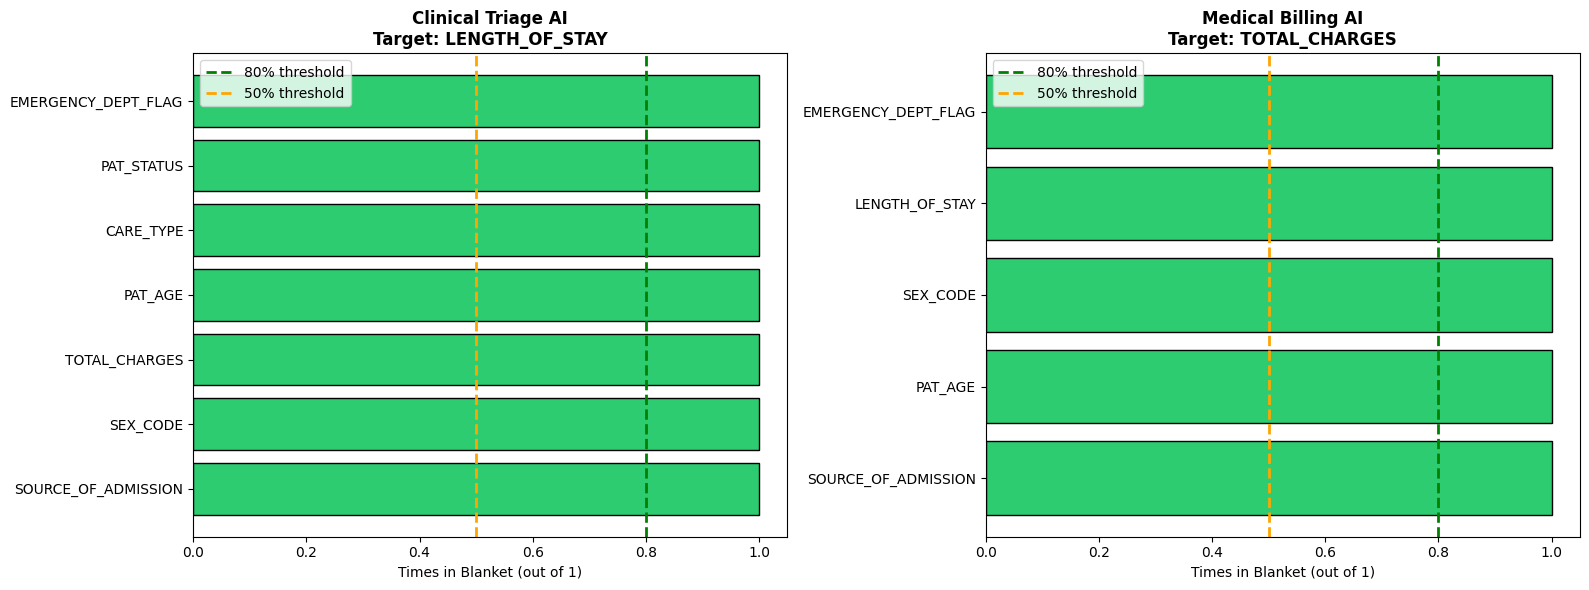

Stability chart saved as 'markov_blanket_stability.png'


  PREDICTION VALIDATION (Random Forest, 5-fold CV)


C:\Users\kyle\AppData\Local\Temp\ipykernel_35576\4094718382.py:145: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")



Running 5-fold cross-validation...


  Clinical Triage AI
  Target: LENGTH_OF_STAY
  Blanket vars: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES', 'PAT_AGE', 'CARE_TYPE', 'PAT_STATUS', 'EMERGENCY_DEPT_FLAG']
  ---
  ALL features (13 vars):     0.5755 (+/- 0.0028)
  BLANKET only  (7 vars):     0.5463 (+/- 0.0025)
  Accuracy drop:                  0.0292
  Features eliminated:            6
  >>> SMALL DROP — blanket captures most of the signal

  Medical Billing AI
  Target: TOTAL_CHARGES
  Blanket vars: ['SOURCE_OF_ADMISSION', 'PAT_AGE', 'SEX_CODE', 'LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG']
  ---
  ALL features (13 vars):     0.6043 (+/- 0.0041)
  BLANKET only  (5 vars):     0.5356 (+/- 0.0037)
  Accuracy drop:                  0.0687
  Features eliminated:            8
  >>> NOTABLE DROP — consider adding borderline (50%+) variables


  FINAL DATA MINIMIZATION SUMMARY

  Clinical AI (LENGTH_OF_STAY):
    Keep: ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES', 'PAT_AGE', 'CARE_T

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C', 'PAT_STATUS': 'C', 'SECONDARY_PAYMENT_SRC': 'C', 'CARE_TYPE': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURC

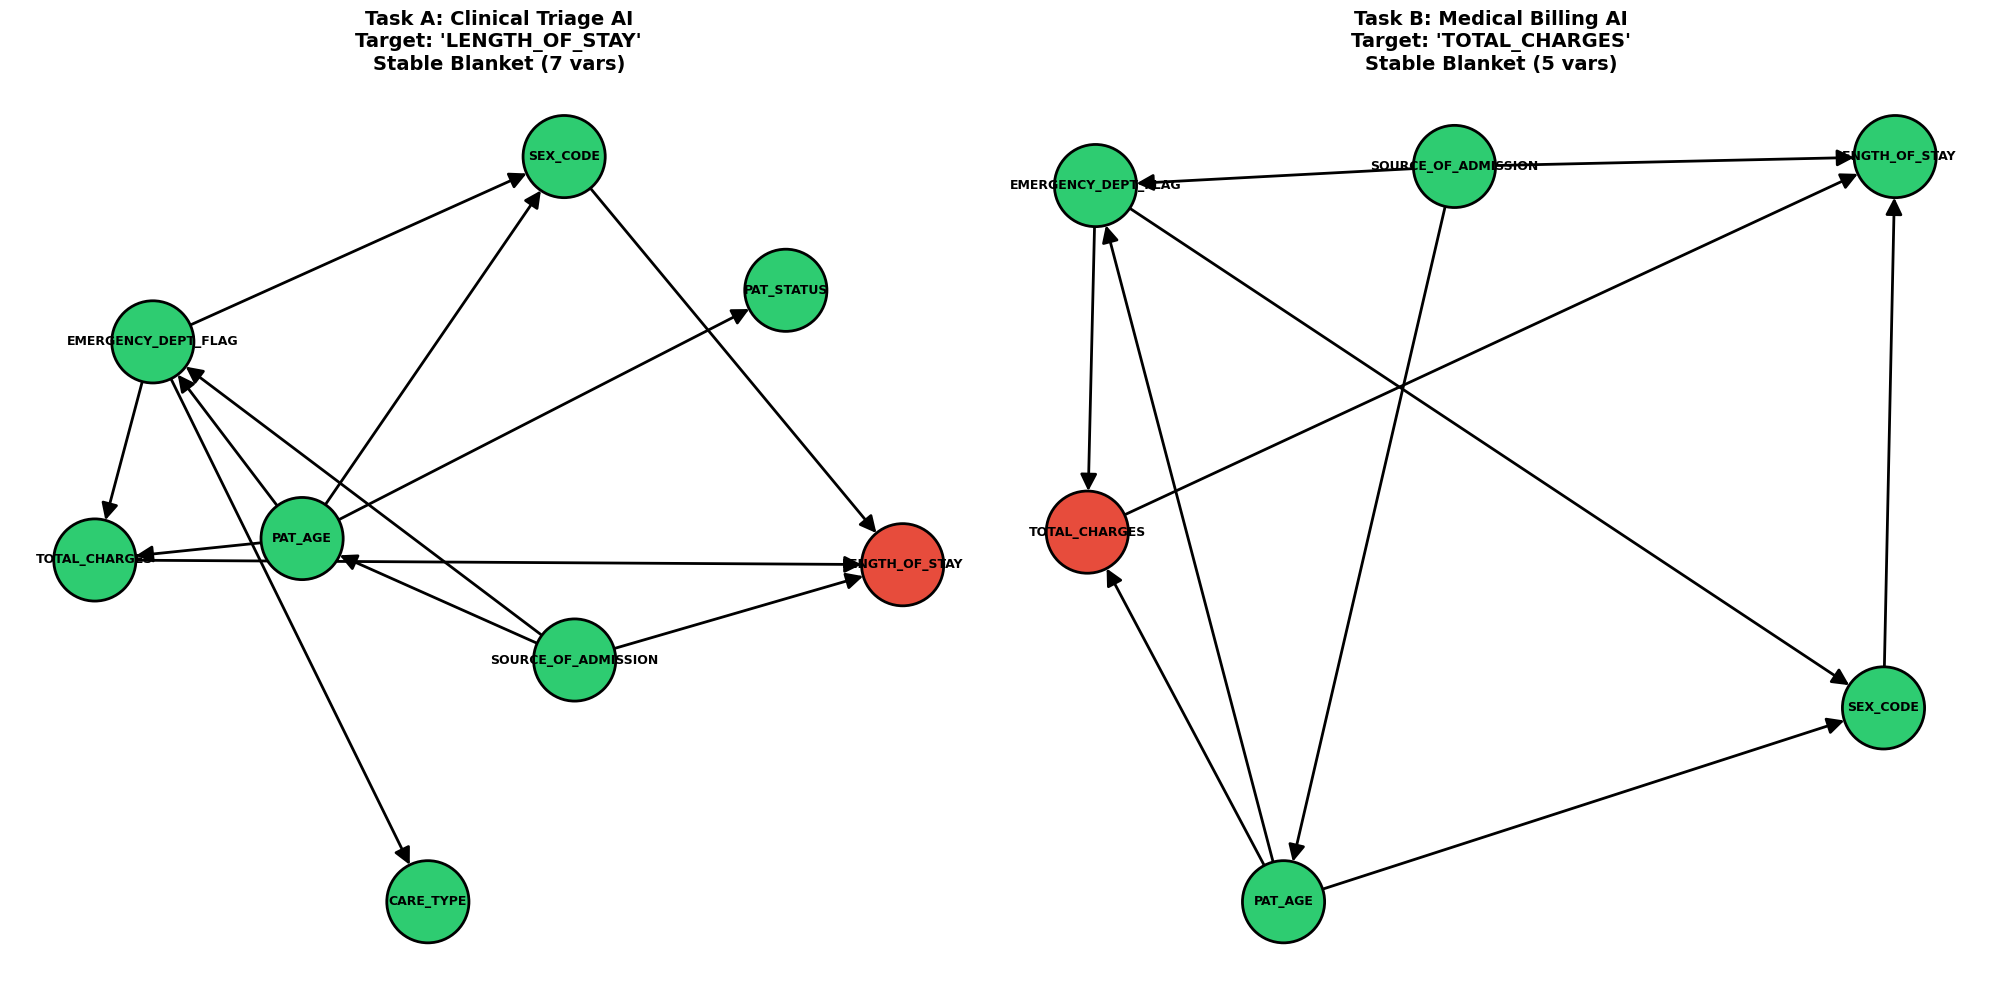

Network graphs saved as 'markov_blanket_graphs.png'


In [17]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. LOAD FULL DATASET
# ==========================================
print("Loading the full Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])
print(f"Total rows available: {len(df_vault)}")

# ==========================================
# 2. BOOTSTRAP SETTINGS
# ==========================================
N_RUNS = 1
SAMPLE_SIZE = 706000  # 100k samples from 706k for maximum stability
STABILITY_THRESHOLD = 0.80  # 80% = stable core

clinical_counter = Counter()
financial_counter = Counter()

# ==========================================
# 3. BOOTSTRAP LOOP
# ==========================================
print(f"\n--- Running {N_RUNS} bootstrap iterations (this will take a while) ---\n")

for i in range(N_RUNS):
    if (i + 1) % 10 == 0:
        print(f"Run {i + 1}/{N_RUNS}...")

    df_sample = df_vault.sample(n=SAMPLE_SIZE, replace=True, random_state=i).copy()

    df_sample['TOTAL_CHARGES'] = pd.qcut(
        df_sample['TOTAL_CHARGES'], q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    df_sample['LENGTH_OF_STAY'] = pd.qcut(
        df_sample['LENGTH_OF_STAY'], q=4,
        labels=['Short', 'Medium', 'Long', 'Extended'],
        duplicates='drop'
    )
    df_sample = df_sample.astype(str)

    try:
        hc = HillClimbSearch(df_sample)
        best_model = hc.estimate(scoring_method="bic-d")
        bn = DiscreteBayesianNetwork(best_model.edges())

        mb_clinical = bn.get_markov_blanket("LENGTH_OF_STAY")
        mb_financial = bn.get_markov_blanket("TOTAL_CHARGES")

        for var in mb_clinical:
            clinical_counter[var] += 1
        for var in mb_financial:
            financial_counter[var] += 1

    except Exception as e:
        print(f"  Run {i + 1} failed: {e}")
        continue

# ==========================================
# 4. STABILITY REPORT
# ==========================================
# List ALL variables (not just ones that appeared in a blanket)
all_vars = sorted([c for c in df_vault.columns if c not in ["LENGTH_OF_STAY", "TOTAL_CHARGES"]])

print("\n" + "=" * 65)
print(f"  MARKOV BLANKET STABILITY REPORT  ({N_RUNS} bootstrap runs)")
print("=" * 65)
print(f"{'Variable':<25} {'Clinical (LOS)':<18} {'Financial (TC)':<18}")
print("-" * 65)
for var in all_vars:
    c_count = clinical_counter.get(var, 0)
    f_count = financial_counter.get(var, 0)
    c_pct = f"{c_count}/{N_RUNS} ({c_count/N_RUNS*100:.0f}%)"
    f_pct = f"{f_count}/{N_RUNS} ({f_count/N_RUNS*100:.0f}%)"
    print(f"{var:<25} {c_pct:<18} {f_pct:<18}")
print("-" * 65)

# ==========================================
# 5. AUTO-EXTRACT STABLE BLANKET VARIABLES
# ==========================================
threshold_count = int(N_RUNS * STABILITY_THRESHOLD)

clinical_blanket = [var for var, count in clinical_counter.items() if count >= threshold_count]
financial_blanket = [var for var, count in financial_counter.items() if count >= threshold_count]

print(f"\nStable Clinical Blanket (80%+):  {clinical_blanket}")
print(f"Stable Financial Blanket (80%+): {financial_blanket}")

if not clinical_blanket:
    print("\nWARNING: No variables hit 80% for Clinical. Lowering threshold to 50%.")
    clinical_blanket = [var for var, count in clinical_counter.items() if count >= N_RUNS * 0.5]
if not financial_blanket:
    print("WARNING: No variables hit 80% for Financial. Lowering threshold to 50%.")
    financial_blanket = [var for var, count in financial_counter.items() if count >= N_RUNS * 0.5]

# ==========================================
# 6. STABILITY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if clinical_counter:
    vars_c = sorted(clinical_counter.keys(), key=lambda x: clinical_counter[x], reverse=True)
    counts_c = [clinical_counter[v] for v in vars_c]
    colors_c = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_c]
    axes[0].barh(vars_c, counts_c, color=colors_c, edgecolor='black')
    axes[0].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[0].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[0].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[0].set_title("Clinical Triage AI\nTarget: LENGTH_OF_STAY", fontweight='bold')
    axes[0].legend()

if financial_counter:
    vars_f = sorted(financial_counter.keys(), key=lambda x: financial_counter[x], reverse=True)
    counts_f = [financial_counter[v] for v in vars_f]
    colors_f = ['#2ecc71' if c >= N_RUNS * 0.8 else '#f39c12' if c >= N_RUNS * 0.5 else '#e74c3c' for c in counts_f]
    axes[1].barh(vars_f, counts_f, color=colors_f, edgecolor='black')
    axes[1].axvline(x=N_RUNS * 0.8, color='green', linestyle='--', linewidth=2, label='80% threshold')
    axes[1].axvline(x=N_RUNS * 0.5, color='orange', linestyle='--', linewidth=2, label='50% threshold')
    axes[1].set_xlabel(f'Times in Blanket (out of {N_RUNS})')
    axes[1].set_title("Medical Billing AI\nTarget: TOTAL_CHARGES", fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.savefig("markov_blanket_stability.png", dpi=150, bbox_inches='tight')
plt.show()
print("Stability chart saved as 'markov_blanket_stability.png'")

# ==========================================
# 7. PREDICTION VALIDATION
# ==========================================
print("\n\n" + "=" * 65)
print("  PREDICTION VALIDATION (Random Forest, 5-fold CV)")
print("=" * 65)

# Use a 50k sample for model training
df_pred = pd.read_csv("Cleaned_Patient_Vault.csv")
df_pred = df_pred.drop(columns=["RECORD_ID"])
df_pred = df_pred.sample(n=50000, random_state=42).copy()

# Discretize same as before
df_pred['TOTAL_CHARGES'] = pd.qcut(df_pred['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_pred['LENGTH_OF_STAY'] = pd.qcut(df_pred['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Encode for sklearn
for col in df_pred.columns:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

def compare_models(df, target, blanket_features, task_name):
    all_features = [c for c in df.columns if c != target]
    y = df[target]

    # Model A: ALL features
    X_all = df[all_features]
    scores_all = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_all, y, cv=5, scoring='accuracy'
    )

    # Model B: BLANKET ONLY
    X_blanket = df[blanket_features]
    scores_blanket = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        X_blanket, y, cv=5, scoring='accuracy'
    )

    drop = scores_all.mean() - scores_blanket.mean()

    print(f"\n  {task_name}")
    print(f"  Target: {target}")
    print(f"  Blanket vars: {blanket_features}")
    print(f"  ---")
    print(f"  ALL features ({len(all_features)} vars):     {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")
    print(f"  BLANKET only  ({len(blanket_features)} vars):     {scores_blanket.mean():.4f} (+/- {scores_blanket.std():.4f})")
    print(f"  Accuracy drop:                  {drop:.4f}")
    print(f"  Features eliminated:            {len(all_features) - len(blanket_features)}")

    if drop < 0.02:
        print(f"  >>> MINIMAL DROP — blanket is sufficient for data minimization")
    elif drop < 0.05:
        print(f"  >>> SMALL DROP — blanket captures most of the signal")
    else:
        print(f"  >>> NOTABLE DROP — consider adding borderline (50%+) variables")

    return scores_all.mean(), scores_blanket.mean()

print("\nRunning 5-fold cross-validation...\n")

all_acc_c, blanket_acc_c = compare_models(df_pred, "LENGTH_OF_STAY", clinical_blanket, "Clinical Triage AI")
all_acc_f, blanket_acc_f = compare_models(df_pred, "TOTAL_CHARGES", financial_blanket, "Medical Billing AI")

# ==========================================
# 8. FINAL SUMMARY
# ==========================================
print("\n\n" + "=" * 65)
print("  FINAL DATA MINIMIZATION SUMMARY")
print("=" * 65)
print(f"\n  Clinical AI (LENGTH_OF_STAY):")
print(f"    Keep: {clinical_blanket}")
print(f"    Accuracy: {blanket_acc_c:.4f} vs {all_acc_c:.4f} (all features)")

print(f"\n  Financial AI (TOTAL_CHARGES):")
print(f"    Keep: {financial_blanket}")
print(f"    Accuracy: {blanket_acc_f:.4f} vs {all_acc_f:.4f} (all features)")

print(f"\n  Conclusion: Collect ONLY the blanket variables.")
print(f"  Everything else can be dropped with minimal accuracy loss.")
print("=" * 65)

# ==========================================
# 9. MARKOV BLANKET NETWORK GRAPHS
# ==========================================
import networkx as nx

print("\n\nGenerating Markov Blanket network diagrams...")
print("Running one final structure learning on a large sample for the graph edges...")

# Learn one final structure on a big sample for the graph
df_graph = df_vault.sample(n=min(100000, len(df_vault)), random_state=99).copy()
df_graph['TOTAL_CHARGES'] = pd.qcut(df_graph['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_graph['LENGTH_OF_STAY'] = pd.qcut(df_graph['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')
df_graph = df_graph.astype(str)

hc_final = HillClimbSearch(df_graph)
final_model = hc_final.estimate(scoring_method="bic-d")
bn_final = DiscreteBayesianNetwork(final_model.edges())

G_full = nx.DiGraph()
G_full.add_nodes_from(list(bn_final.nodes()))
G_full.add_edges_from(list(bn_final.edges()))

targets = {
    "Task A: Clinical Triage AI": ("LENGTH_OF_STAY", clinical_blanket),
    "Task B: Medical Billing AI": ("TOTAL_CHARGES", financial_blanket)
}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (title, (target_node, mb_nodes)) in zip(axes, targets.items()):
    # Build subgraph of target + its stable blanket members
    focus_nodes = [target_node] + mb_nodes
    sub_G = G_full.subgraph(focus_nodes).copy()
    
    # Also add any edges from the full graph between these nodes
    # (some blanket members may not have edges in this particular run,
    #  but we still want to show them as part of the blanket)
    for node in mb_nodes:
        if node not in sub_G.nodes():
            sub_G.add_node(node)
    
    # Layout
    pos = nx.spring_layout(sub_G, seed=42, k=2)
    
    # Colors: target = red, stable blanket = green, borderline = orange
    node_colors = []
    for node in sub_G.nodes():
        if node == target_node:
            node_colors.append("#e74c3c")  # red
        else:
            node_colors.append("#2ecc71")  # green (stable)
    
    # Draw nodes
    nx.draw_networkx_nodes(
        sub_G, pos, ax=ax, 
        node_size=3500, 
        node_color=node_colors, 
        edgecolors="black", 
        linewidths=2
    )
    
    # Draw edges with arrows
    nx.draw_networkx_edges(
        sub_G, pos, ax=ax,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=25,
        edge_color="black",
        width=2,
        node_size=3500
    )
    
    # Labels
    nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=9, font_weight="bold")
    
    ax.axis("off")
    ax.set_title(f"{title}\nTarget: '{target_node}'\nStable Blanket ({len(mb_nodes)} vars)", 
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("markov_blanket_graphs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Network graphs saved as 'markov_blanket_graphs.png'")

Loading Patient Vault...
Total rows: 706472
Using sample: 50000 rows

  Clinical Triage AI — Target: LENGTH_OF_STAY

  [1/3] Random Forest (Gini importance)...
         Test accuracy: 0.5725
         Top features:
           PRINC_DIAG_CODE              0.2195
           PAT_ZIP                      0.2162
           PAT_AGE                      0.1284
           TOTAL_CHARGES                0.1019
           FIRST_PAYMENT_SRC            0.0704
           PAT_STATUS                   0.0622
           SECONDARY_PAYMENT_SRC        0.0509
           SOURCE_OF_ADMISSION          0.0422

  [2/3] Permutation importance (on test set)...
         Top features:
           TOTAL_CHARGES                0.1721 (+/- 0.0043)
           PRINC_DIAG_CODE              0.0481 (+/- 0.0029)
           PAT_STATUS                   0.0352 (+/- 0.0027)
           EMERGENCY_DEPT_FLAG          0.0253 (+/- 0.0020)
           SOURCE_OF_ADMISSION          0.0106 (+/- 0.0021)
           PAT_AGE                    

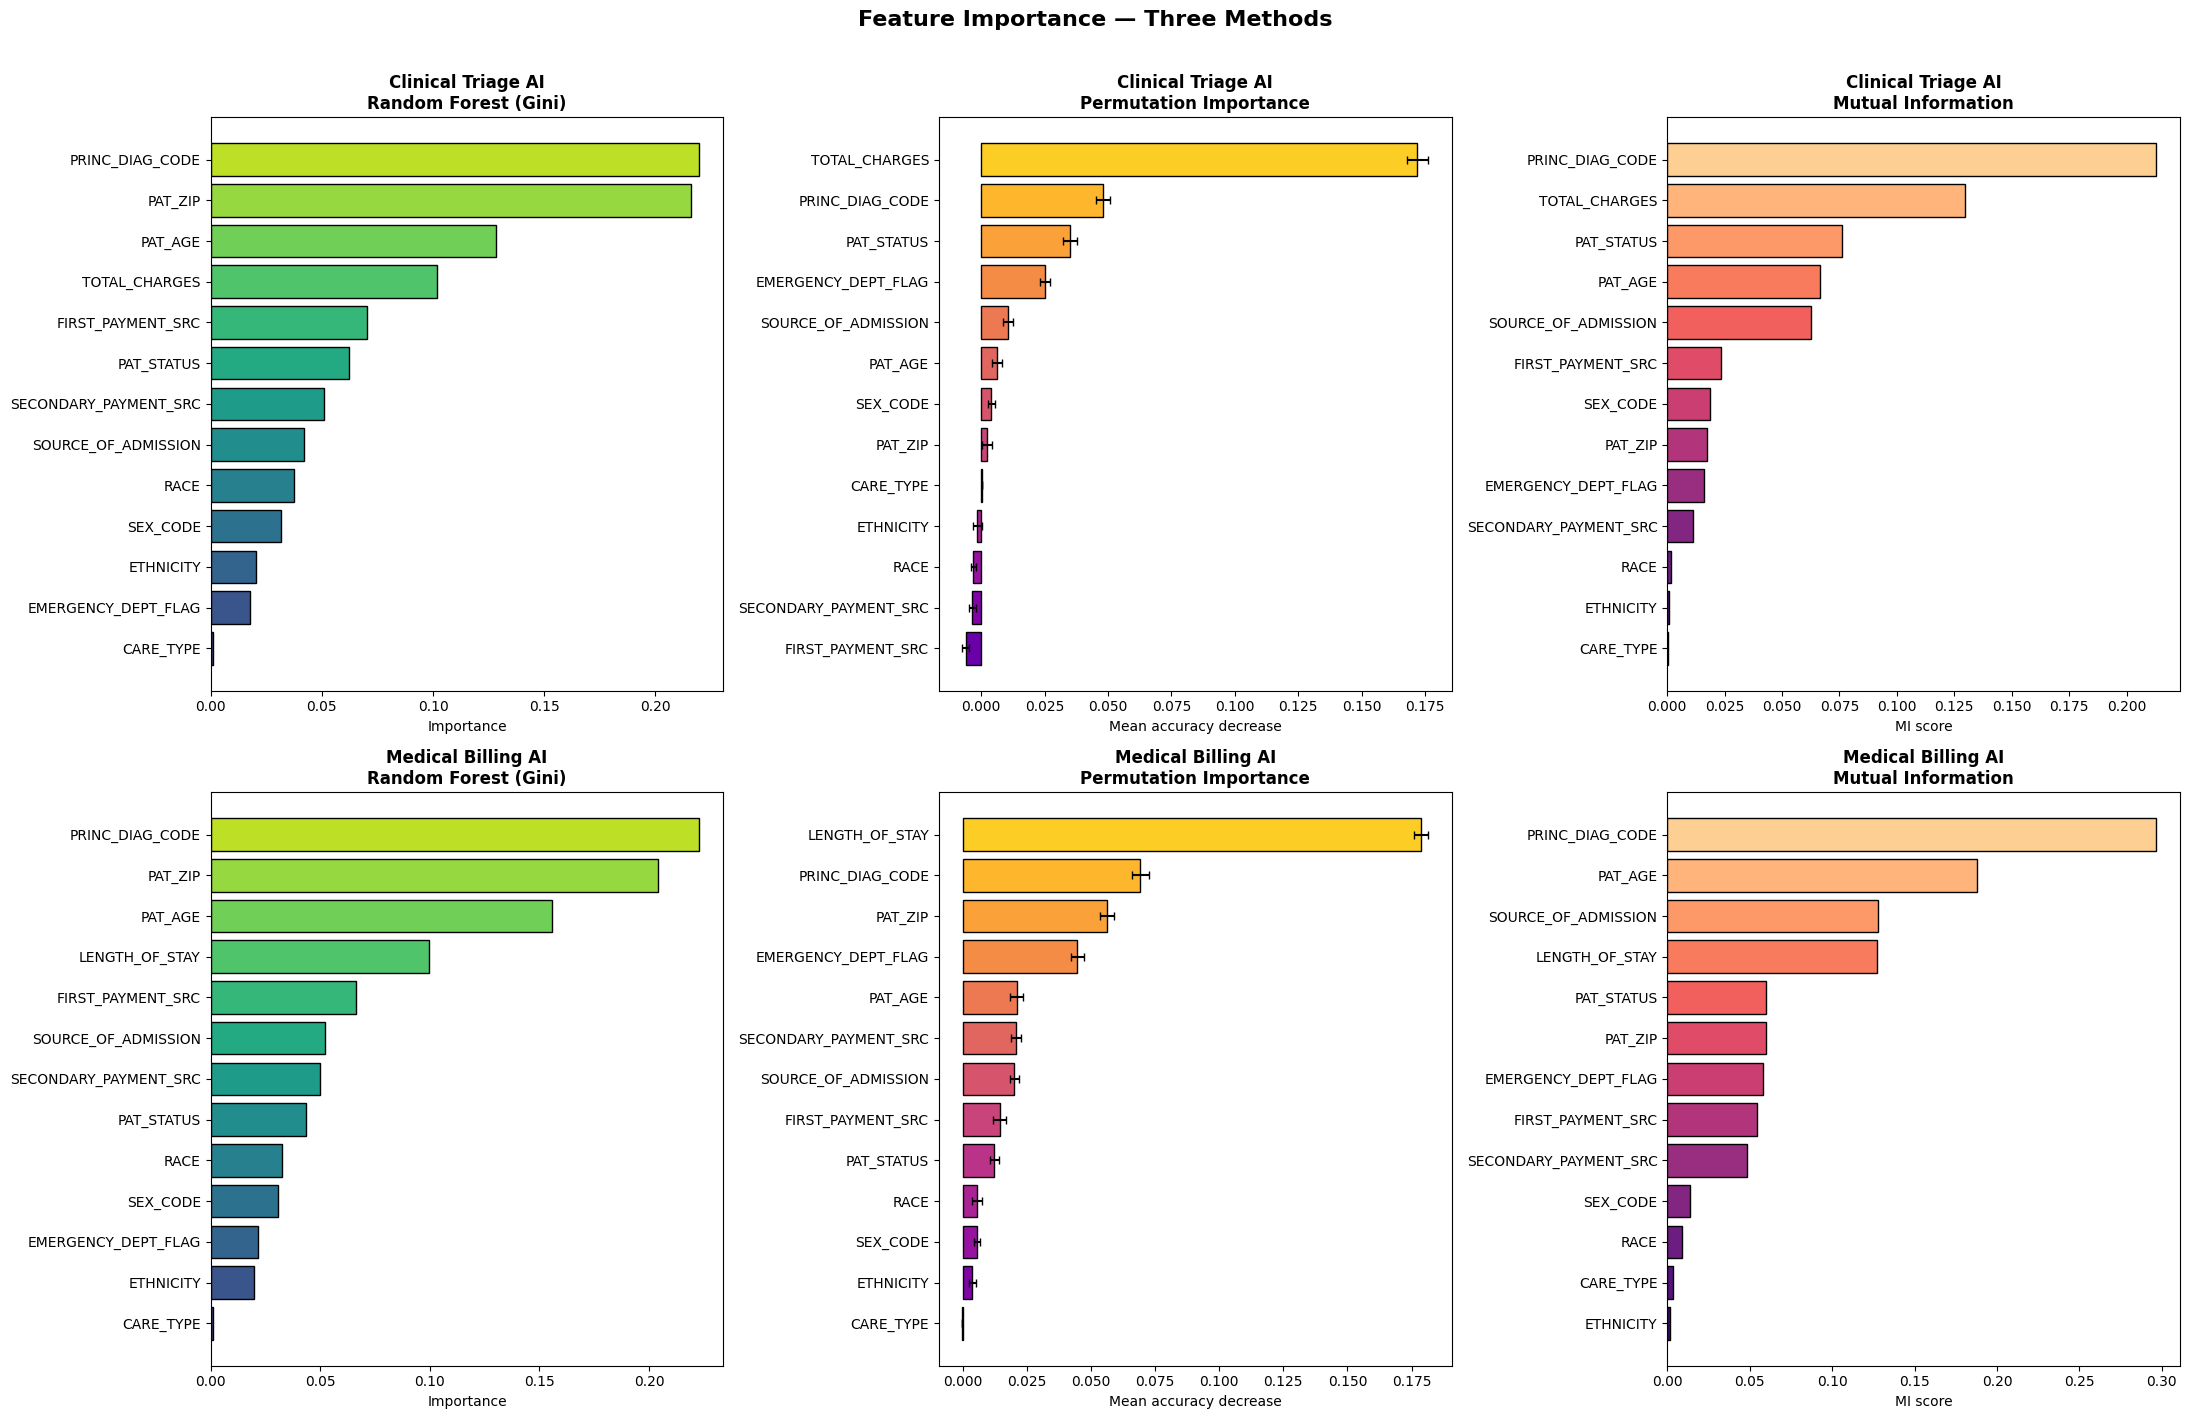


Chart saved as 'feature_importance.png'


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("Loading Patient Vault...")
df = pd.read_csv("Cleaned_Patient_Vault.csv")
df = df.drop(columns=["RECORD_ID"])
print(f"Total rows: {len(df)}")

# Use 50k sample for speed
df = df.sample(n=50000, random_state=42).copy()
print(f"Using sample: {len(df)} rows")

# Discretize targets
df['TOTAL_CHARGES'] = pd.qcut(df['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df['LENGTH_OF_STAY'] = pd.qcut(df['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Encode all columns
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

targets = {
    "Clinical Triage AI": "LENGTH_OF_STAY",
    "Medical Billing AI": "TOTAL_CHARGES"
}

all_results = {}

for task_name, target in targets.items():
    print(f"\n{'='*65}")
    print(f"  {task_name} — Target: {target}")
    print(f"{'='*65}")

    features = [c for c in df.columns if c != target]
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ------------------------------------------
    # METHOD 1: Random Forest Feature Importance
    # ------------------------------------------
    print("\n  [1/3] Random Forest (Gini importance)...")
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    print(f"         Test accuracy: {acc:.4f}")

    rf_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    print("         Top features:")
    for feat, imp in rf_importance.head(8).items():
        print(f"           {feat:<28} {imp:.4f}")

    # ------------------------------------------
    # METHOD 2: Permutation Importance
    # ------------------------------------------
    print("\n  [2/3] Permutation importance (on test set)...")
    perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
    perm_std = pd.Series(perm.importances_std, index=features)
    print("         Top features:")
    for feat, imp in perm_importance.head(8).items():
        print(f"           {feat:<28} {imp:.4f} (+/- {perm_std[feat]:.4f})")

    # ------------------------------------------
    # METHOD 3: Mutual Information
    # ------------------------------------------
    print("\n  [3/3] Mutual information...")
    mi_scores = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
    mi_importance = pd.Series(mi_scores, index=features).sort_values(ascending=False)
    print("         Top features:")
    for feat, imp in mi_importance.head(8).items():
        print(f"           {feat:<28} {imp:.4f}")

    all_results[task_name] = {
        "target": target,
        "rf": rf_importance,
        "perm": perm_importance,
        "perm_std": perm_std,
        "mi": mi_importance
    }

# ==========================================
# 2. COMBINED RANKING TABLE
# ==========================================
print(f"\n\n{'='*65}")
print("  COMBINED FEATURE IMPORTANCE RANKINGS")
print(f"{'='*65}")

for task_name, res in all_results.items():
    print(f"\n  {task_name} — Target: {res['target']}")
    print(f"  {'Feature':<28} {'RF Gini':>10} {'Perm Imp':>10} {'Mut Info':>10} {'Avg Rank':>10}")
    print(f"  {'-'*68}")

    features = list(res['rf'].index)

    # Compute ranks (1 = most important)
    rf_rank = res['rf'].rank(ascending=False)
    perm_rank = res['perm'].rank(ascending=False)
    mi_rank = res['mi'].rank(ascending=False)

    avg_rank = ((rf_rank + perm_rank + mi_rank) / 3).sort_values()

    for feat in avg_rank.index:
        print(f"  {feat:<28} {res['rf'][feat]:>10.4f} {res['perm'][feat]:>10.4f} {res['mi'][feat]:>10.4f} {avg_rank[feat]:>10.1f}")

# ==========================================
# 3. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for row, (task_name, res) in enumerate(all_results.items()):
    # RF importance
    ax = axes[row][0]
    data_sorted = res['rf'].sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(data_sorted)))
    ax.barh(data_sorted.index, data_sorted.values, color=colors, edgecolor='black')
    ax.set_title(f"{task_name}\nRandom Forest (Gini)", fontweight='bold')
    ax.set_xlabel("Importance")

    # Permutation importance
    ax = axes[row][1]
    data_sorted = res['perm'].sort_values(ascending=True)
    std_sorted = res['perm_std'][data_sorted.index]
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(data_sorted)))
    ax.barh(data_sorted.index, data_sorted.values, xerr=std_sorted.values, color=colors, edgecolor='black', capsize=3)
    ax.set_title(f"{task_name}\nPermutation Importance", fontweight='bold')
    ax.set_xlabel("Mean accuracy decrease")

    # Mutual information
    ax = axes[row][2]
    data_sorted = res['mi'].sort_values(ascending=True)
    colors = plt.cm.magma(np.linspace(0.2, 0.9, len(data_sorted)))
    ax.barh(data_sorted.index, data_sorted.values, color=colors, edgecolor='black')
    ax.set_title(f"{task_name}\nMutual Information", fontweight='bold')
    ax.set_xlabel("MI score")

plt.suptitle("Feature Importance — Three Methods", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'feature_importance.png'")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# DIAGNOSTIC TEST: Are PAT_ZIP and PRINC_DIAG_CODE
# genuinely redundant, or is the blanket missing them?
# ==========================================
# 
# Logic:
#   A) Blanket only           → baseline
#   B) Blanket + PAT_ZIP      → does ZIP add signal?
#   C) Blanket + PRINC_DIAG   → does diagnosis add signal?
#   D) Blanket + both         → combined effect
#   E) ALL features           → ceiling
#
# If B/C/D show meaningful accuracy gains over A,
# the blanket is missing real predictive variables.
# If they don't, the blanket already captures that signal.
# ==========================================

print("Loading Patient Vault...")
df = pd.read_csv("Cleaned_Patient_Vault.csv")
df = df.drop(columns=["RECORD_ID"])
df = df.sample(n=50000, random_state=42).copy()
print(f"Using {len(df)} rows")

# Discretize targets
df['TOTAL_CHARGES'] = pd.qcut(df['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df['LENGTH_OF_STAY'] = pd.qcut(df['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Encode
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ==========================================
# SET YOUR BLANKETS HERE
# (paste whatever your hill climbing found)
# ==========================================
# Example — replace these with your actual results:
clinical_blanket = ['SOURCE_OF_ADMISSION', 'SEX_CODE', 'TOTAL_CHARGES', 'PAT_AGE', 'CARE_TYPE', 'PAT_STATUS', 'EMERGENCY_DEPT_FLAG']
financial_blanket = ['SOURCE_OF_ADMISSION', 'PAT_AGE', 'SEX_CODE', 'LENGTH_OF_STAY', 'EMERGENCY_DEPT_FLAG']


# Variables to test
TEST_VARS = ["PAT_ZIP", "PRINC_DIAG_CODE"]


def run_diagnostic(df, target, blanket, test_vars, task_name):
    print(f"\n{'='*70}")
    print(f"  DIAGNOSTIC: {task_name}")
    print(f"  Target: {target}")
    print(f"  Base blanket: {blanket}")
    print(f"  Testing addition of: {test_vars}")
    print(f"{'='*70}")

    all_features = [c for c in df.columns if c != target]
    y = df[target]

    results = {}

    # A) Blanket only
    if blanket:
        scores = cross_val_score(
            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
            df[blanket], y, cv=5, scoring='accuracy'
        )
        results['A) Blanket only'] = (blanket, scores.mean(), scores.std())
    else:
        print("  WARNING: Empty blanket — skipping blanket-only test")
        results['A) Blanket only'] = ([], 0.0, 0.0)

    # B) Blanket + each test var individually
    for var in test_vars:
        if var in blanket:
            label = f"B) Blanket + {var}"
            results[label] = (blanket, results['A) Blanket only'][1], results['A) Blanket only'][2])
            print(f"  Note: {var} is already in the blanket")
            continue

        features = list(set(blanket + [var]))
        scores = cross_val_score(
            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
            df[features], y, cv=5, scoring='accuracy'
        )
        label = f"B) Blanket + {var}"
        results[label] = (features, scores.mean(), scores.std())

    # C) Blanket + all test vars
    added = [v for v in test_vars if v not in blanket]
    if len(added) > 1:
        features = list(set(blanket + added))
        scores = cross_val_score(
            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
            df[features], y, cv=5, scoring='accuracy'
        )
        results['C) Blanket + both'] = (features, scores.mean(), scores.std())

    # D) All features
    scores = cross_val_score(
        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        df[all_features], y, cv=5, scoring='accuracy'
    )
    results['D) All features'] = (all_features, scores.mean(), scores.std())

    # Print results
    print(f"\n  {'Configuration':<35} {'# Vars':>7} {'Accuracy':>10} {'Std':>8} {'vs Blanket':>12}")
    print(f"  {'-'*72}")

    base_acc = results['A) Blanket only'][1]

    for label, (feats, acc, std) in results.items():
        diff = acc - base_acc
        diff_str = f"{diff:+.4f}" if label != 'A) Blanket only' else "---"
        print(f"  {label:<35} {len(feats):>7} {acc:>10.4f} {std:>8.4f} {diff_str:>12}")

    # Interpretation
    print(f"\n  --- INTERPRETATION ---")
    for var in test_vars:
        label = f"B) Blanket + {var}"
        if label in results and var not in blanket:
            diff = results[label][1] - base_acc
            if diff > 0.02:
                print(f"  {var}: +{diff:.4f} accuracy — SIGNIFICANT GAIN")
                print(f"    → The blanket is likely MISSING this variable.")
                print(f"    → CI tests may have failed due to high cardinality.")
            elif diff > 0.005:
                print(f"  {var}: +{diff:.4f} accuracy — SMALL GAIN")
                print(f"    → Borderline. The variable adds some signal not fully")
                print(f"      captured by the blanket, but it's modest.")
            else:
                print(f"  {var}: +{diff:.4f} accuracy — NEGLIGIBLE")
                print(f"    → The blanket already captures this variable's signal.")
                print(f"    → It's genuinely redundant given the other blanket members.")
        elif var in blanket:
            print(f"  {var}: Already in blanket — no test needed.")

    return results


print("\nRunning 5-fold CV with 200 trees (this may take a minute)...\n")

results_clinical = run_diagnostic(
    df, "LENGTH_OF_STAY", clinical_blanket, TEST_VARS, "Clinical Triage AI"
)

results_financial = run_diagnostic(
    df, "TOTAL_CHARGES", financial_blanket, TEST_VARS, "Medical Billing AI"
)

# ==========================================
# VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (task_name, results) in zip(axes, [
    ("Clinical Triage AI\n(LENGTH_OF_STAY)", results_clinical),
    ("Medical Billing AI\n(TOTAL_CHARGES)", results_financial)
]):
    labels = list(results.keys())
    accs = [results[l][1] for l in labels]
    stds = [results[l][2] for l in labels]

    # Short labels for chart
    short_labels = []
    for l in labels:
        short_labels.append(l.split(') ')[1] if ') ' in l else l)

    colors = ['#3498db', '#e67e22', '#e67e22', '#2ecc71', '#95a5a6'][:len(labels)]

    bars = ax.barh(short_labels, accs, xerr=stds, color=colors,
                   edgecolor='black', capsize=4, height=0.6)

    # Add accuracy labels on bars
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', ha='right', va='center', fontweight='bold',
                fontsize=10, color='white')

    base_acc = accs[0]
    ax.axvline(x=base_acc, color='blue', linestyle='--', alpha=0.5, label='Blanket baseline')

    ax.set_xlabel('5-Fold CV Accuracy', fontsize=11)
    ax.set_title(task_name, fontweight='bold', fontsize=13)
    ax.legend(loc='lower right')

    # Zoom in to relevant range
    min_acc = min(accs) - 0.01
    max_acc = max(accs) + 0.01
    ax.set_xlim(min_acc, max_acc)

plt.suptitle("Diagnostic: Does Adding PAT_ZIP / PRINC_DIAG_CODE Improve the Blanket?",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("blanket_diagnostic.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'blanket_diagnostic.png'")